# Biomedical Image-Analysis Pipeline — Assignment 3
**Modality:** Fluorescence microscopy, synthetic stained-nuclei dataset (DAPI-like)
**Pipeline:** raw image → segmentation → quantitative region features → structured JSON record → short narrative

This notebook implements Tasks 1–4:
1. Data preparation, EDA, and multimodal-LLM (VLM) description via Ollama
2. Classical feature extraction (Otsu + regionprops) and numbers-first LLM interpretation
3. U-Net segmentation, trained and evaluated with Dice / IoU
4. Hybrid pipeline on unseen test images → aggregated CSV of structured records

All figures are saved to `outputs/figures/`, all tabular/JSON results to `outputs/results/`,
so they can be pulled directly into the report.

**Note on the LLM steps (Ollama):** this notebook calls a locally running Ollama server
(`http://localhost:11434`) exactly as in the labs. If Ollama / `llama3.2-vision` is not
running, every LLM call automatically falls back to a clearly-labelled **simulated**
response (built deterministically from the real computed image/feature statistics) so
the notebook still runs top-to-bottom and produces complete outputs. Run this notebook
with Ollama active (`ollama serve`, `ollama pull llama3.2-vision`, `ollama pull llama3.1`)
to get genuine model outputs for the report.


In [1]:
import os

if not os.path.exists("data") or not os.listdir("data"):
    !git clone https://github.com/Nickolay-K/Assingnment-3-dataset.git _dataset_repo
    !unzip -o _dataset_repo/nuclei_dataset.zip -d _dataset_repo/unzipped
    os.makedirs("data", exist_ok=True)
    !cp -r _dataset_repo/unzipped/nuclei_dataset/* data/
    print("Dataset downloaded and extracted into data/")
else:
    print("data/ already populated, skipping download.")

print(sorted(os.listdir("data")))

Cloning into '_dataset_repo'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 10.94 MiB | 21.71 MiB/s, done.
Archive:  _dataset_repo/nuclei_dataset.zip
   creating: _dataset_repo/unzipped/nuclei_dataset/
  inflating: _dataset_repo/unzipped/nuclei_dataset/metadata.csv  
  inflating: _dataset_repo/unzipped/nuclei_dataset/README.md  
   creating: _dataset_repo/unzipped/nuclei_dataset/test/
   creating: _dataset_repo/unzipped/nuclei_dataset/test/images/
  inflating: _dataset_repo/unzipped/nuclei_dataset/test/images/test_001.png  
  inflating: _dataset_repo/unzipped/nuclei_dataset/test/images/test_009.png  
  inflating: _dataset_repo/unzipped/nuclei_dataset/test/images/test_010.png  
  inflating: _dataset_repo/unzipped/nuclei_dataset/test/images/test_011.png  
  inflating: _dataset_repo/unzipped/nuclei_dataset

In [2]:

import os, json, glob, base64, time, random, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from skimage import io, color, filters, morphology, measure, exposure
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import requests

# ---------------- reproducibility ----------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---------------- paths ----------------
DATA_DIR = Path("data")            # dataset root (see download cell below)
FIG_DIR  = Path("outputs/figures")
RES_DIR  = Path("outputs/results")
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256   # common size required by Task 1
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


Torch: 2.11.0+cu128 | CUDA available: True


## Download the dataset

Run this cell once. It clones the assignment dataset repo and unpacks it into `data/`.
If `data/` already exists (e.g. you copied it in yourself) this cell is skipped.


In [3]:

if not DATA_DIR.exists() or not any(DATA_DIR.iterdir()):
    os.system("git clone https://github.com/Nickolay-K/Assingnment-3-dataset.git _dataset_repo")
    os.system("unzip -o _dataset_repo/nuclei_dataset.zip -d _dataset_repo/unzipped")
    os.system("cp -r _dataset_repo/unzipped/nuclei_dataset/* data/")
    print("Dataset downloaded and extracted into data/")
else:
    print("data/ already populated, skipping download.")

print(sorted(os.listdir(DATA_DIR)))


data/ already populated, skipping download.
['README.md', 'dataset_summary.json', 'make_dataset.py', 'metadata.csv', 'test', 'test_corrupted', 'train', 'val']


## Task 1 — Data preparation, EDA, and multimodal LLM description

The dataset images are already 256×256 RGB, so "resize to a common size" is enforced
programmatically below (defensive coding: it will still work if a different-sized
dataset is dropped in). We convert to grayscale for the classical/EDA parts of the
pipeline (Task 2 needs single-channel intensity), while keeping the original RGB for
the VLM, which expects a normal image.


In [4]:

def load_and_prepare(path, size=IMG_SIZE):
    """Load an image, convert to grayscale, resize to (size, size).
    Returns (rgb_uint8, gray_float_0_1)."""
    rgb = io.imread(path)
    if rgb.ndim == 2:
        rgb = color.gray2rgb(rgb)
    rgb = rgb[..., :3]
    gray = color.rgb2gray(rgb)
    if rgb.shape[0] != size or rgb.shape[1] != size:
        from skimage.transform import resize
        rgb = (resize(rgb, (size, size), anti_aliasing=True) * 255).astype(np.uint8)
        gray = resize(gray, (size, size), anti_aliasing=True)
    return rgb, gray

train_images = sorted(glob.glob(str(DATA_DIR / "train" / "images" / "*.png")))
train_masks  = sorted(glob.glob(str(DATA_DIR / "train" / "masks"  / "*.png")))
val_images   = sorted(glob.glob(str(DATA_DIR / "val"   / "images" / "*.png")))
val_masks    = sorted(glob.glob(str(DATA_DIR / "val"   / "masks"  / "*.png")))
test_images  = sorted(glob.glob(str(DATA_DIR / "test"  / "images" / "*.png")))
test_masks   = sorted(glob.glob(str(DATA_DIR / "test"  / "masks"  / "*.png")))

print(f"train: {len(train_images)}  val: {len(val_images)}  test: {len(test_images)}")
metadata = pd.read_csv(DATA_DIR / "metadata.csv")
metadata.head()


train: 80  val: 20  test: 12


,image_id,split,density,n_objects,mean_intensity,area_fraction,seed
0,train_000,train,sparse,10,0.747476,0.019333,20260715
1,train_001,train,normal,29,0.736130,0.086044,20260716
2,train_002,train,normal,17,0.703992,0.040680,20260717
3,train_003,train,normal,36,0.716404,0.101517,20260718
4,train_004,train,dense,85,0.763909,0.202789,20260719


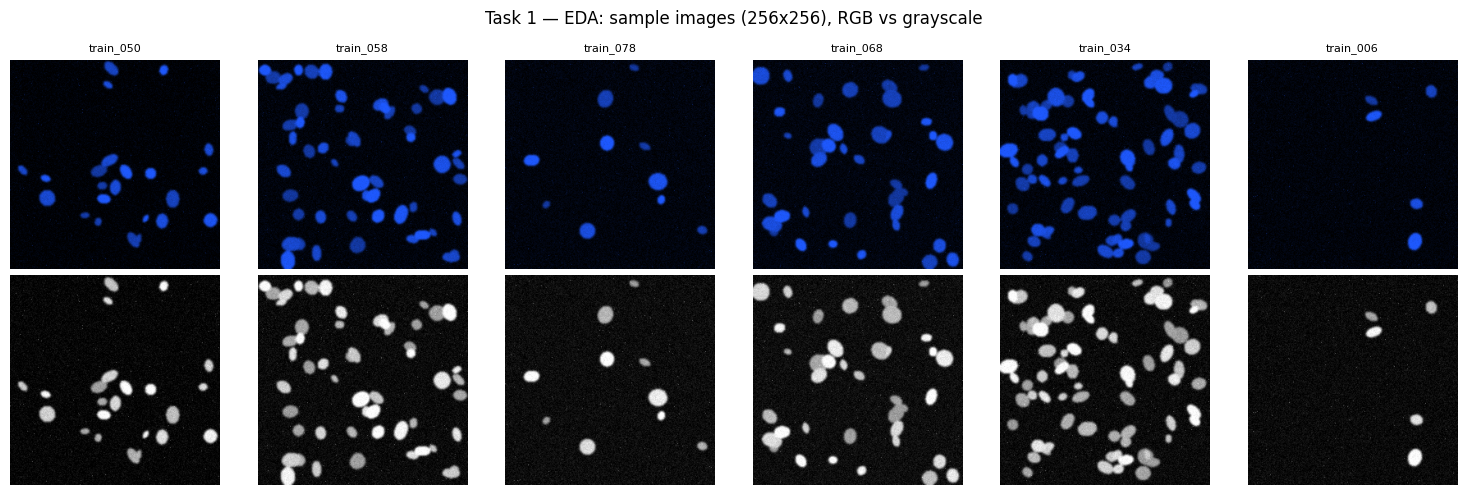

In [5]:

# --- EDA figure 1: sample grid (RGB + grayscale) ---
rng = np.random.default_rng(SEED)
sample_paths = list(rng.choice(train_images, size=6, replace=False))

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i, p in enumerate(sample_paths):
    rgb, gray = load_and_prepare(p)
    axes[0, i].imshow(rgb); axes[0, i].set_title(Path(p).stem, fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(gray, cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("RGB", fontsize=9)
axes[1, 0].set_ylabel("Grayscale", fontsize=9)
plt.suptitle("Task 1 — EDA: sample images (256x256), RGB vs grayscale")
plt.tight_layout()
plt.savefig(FIG_DIR / "task1_sample_grid.png", dpi=150)
plt.show()


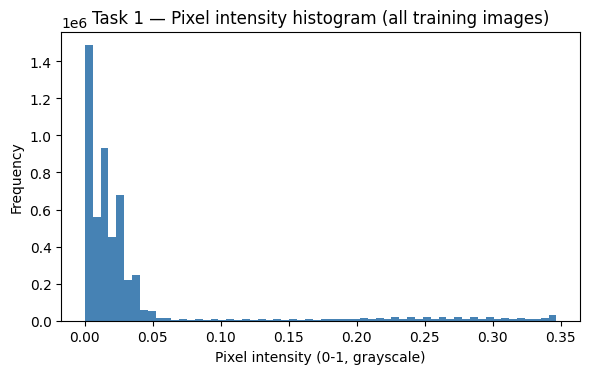

Mean intensity: 0.036 | Std: 0.0702


In [6]:

# --- EDA figure 2: intensity histogram across a batch of training images ---
all_intensities = []
for p in train_images:
    _, gray = load_and_prepare(p)
    all_intensities.append(gray.ravel())
all_intensities = np.concatenate(all_intensities)

plt.figure(figsize=(6, 4))
plt.hist(all_intensities, bins=60, color="steelblue")
plt.xlabel("Pixel intensity (0-1, grayscale)")
plt.ylabel("Frequency")
plt.title("Task 1 — Pixel intensity histogram (all training images)")
plt.tight_layout()
plt.savefig(FIG_DIR / "task1_intensity_histogram.png", dpi=150)
plt.show()

print("Mean intensity:", all_intensities.mean().round(4), "| Std:", all_intensities.std().round(4))


### Local multimodal LLM (VLM) description

We connect to a local Ollama server and query `llama3.2-vision`. Two prompts are
compared:

* a **naive** prompt ("What do you see in this image?") — unconstrained, prone to
  diagnostic language and free text that is hard to parse downstream;
* an **engineered** prompt that anchors the model as a *descriptive, non-diagnostic*
  assistant, forces a strict JSON schema, and explicitly allows `"uncertain"` as a
  valid value — turning the output into something the rest of the pipeline can trust
  and audit.

We also call the engineered prompt twice to demonstrate that outputs are not identical
between runs (LLM sampling variability), which is itself evidence for why the
structured JSON — not the free-text narrative — should be treated as the source of
truth.


In [7]:
import subprocess, time, requests, shutil, os, json

OLLAMA_HOST = "http://localhost:11434"
OLLAMA_BIN_PATH = "/usr/local/bin/ollama"

# Candidate models to try, in priority order. `llama3.2-vision` uses the
# "mllama" architecture, which only newer Ollama server builds understand
# (support was added in Ollama >= 0.4). If the installed server is too old
# it fails with an "unknown model architecture: mllama" error on every call.
# Per the module announcement (19 Aug), if that happens we now automatically
# fall back to alternative local vision models instead of failing silently.
VLM_CANDIDATES  = ["llama3.2-vision", "qwen2.5vl", "qwen2.5vl:7b", "minicpm-v"]
TEXT_CANDIDATES = ["llama3.1", "mistral", "gemma2"]

# Known-good pinned fallback release: confirmed to support the mllama
# (vision) architecture and to ship a plain .tgz asset (no zstd needed),
# used only if we can't resolve "latest" dynamically (e.g. GitHub API
# rate-limited).
FALLBACK_TAG = "v0.5.7"


def ollama_available(host=OLLAMA_HOST):
    try:
        r = requests.get(f"{host}/api/tags", timeout=2)
        return r.status_code == 200
    except Exception:
        return False


def _extract_ollama_tarball(archive_path, is_zst):
    """Extract a downloaded Ollama release tarball (bin/ + lib/ layout) into
    /usr/local, matching what the official installer does, so the binary can
    find its bundled libraries at runtime."""
    try:
        if is_zst:
            subprocess.run(["tar", "--zstd", "-xf", archive_path, "-C", "/usr/local"],
                            check=True, capture_output=True, text=True, timeout=300)
        else:
            subprocess.run(["tar", "-xzf", archive_path, "-C", "/usr/local"],
                            check=True, capture_output=True, text=True, timeout=300)
        return os.path.exists(OLLAMA_BIN_PATH) and os.access(OLLAMA_BIN_PATH, os.X_OK)
    except Exception as e:
        print("  Extraction failed:", e)
        return False


def _download_ollama_release(tag):
    """Try the modern .tar.zst asset first, then the older .tgz asset name,
    since the packaging format has changed across Ollama versions."""
    for ext, is_zst in [("tar.zst", True), ("tgz", False)]:
        url = f"https://github.com/ollama/ollama/releases/download/{tag}/ollama-linux-amd64.{ext}"
        archive_path = f"/tmp/ollama_release.{ext}"
        try:
            print(f"  Trying {url} ...")
            r = subprocess.run(
                ["curl", "-fsSL", "-A", "Mozilla/5.0", "-o", archive_path, url],
                capture_output=True, text=True, timeout=900,
            )
            if r.returncode == 0 and os.path.exists(archive_path) and os.path.getsize(archive_path) > 1_000_000:
                print(f"  Downloaded {os.path.getsize(archive_path)/1e6:.0f} MB, extracting...")
                if _extract_ollama_tarball(archive_path, is_zst):
                    os.remove(archive_path)
                    return True
            else:
                print(f"  '{ext}' asset not available for {tag} (this is normal for some versions).")
        except Exception as e:
            print(f"  Download of '{ext}' asset failed:", e)
        finally:
            if os.path.exists(archive_path):
                os.remove(archive_path)
    return False


def _install_ollama_binary():
    """Install a CURRENT Ollama build. Tries the official install script
    first (always up to date, handles GPU/CPU auto-detection); falls back to
    a direct GitHub-release download only if the script can't be reached
    (e.g. a restricted network). This deliberately avoids pinning an old
    Ollama version, since an old server is what causes the
    'unknown model architecture: mllama' failure for llama3.2-vision."""
    try:
        print("Installing Ollama via the official install script (ollama.com)...")
        result = subprocess.run(
            "curl -fsSL https://ollama.com/install.sh | sh",
            shell=True, capture_output=True, text=True, timeout=600,
        )
        if os.path.exists(OLLAMA_BIN_PATH) and os.access(OLLAMA_BIN_PATH, os.X_OK):
            print("Ollama installed via official script.")
            return True
        print("  Install script did not produce a working binary "
              f"(this network may block ollama.com): {(result.stderr or '')[-300:]}")
    except Exception as e:
        print("  Official install script unavailable:", e)

    print("Falling back to a direct GitHub-release download...")
    tag = FALLBACK_TAG
    try:
        api = requests.get("https://api.github.com/repos/ollama/ollama/releases/latest", timeout=10)
        if api.ok:
            tag = api.json().get("tag_name", FALLBACK_TAG)
            print(f"  Latest Ollama release resolved to: {tag}")
    except Exception as e:
        print(f"  Could not resolve latest release ({e}); using pinned fallback {FALLBACK_TAG}.")

    if _download_ollama_release(tag):
        return True
    if tag != FALLBACK_TAG:
        print(f"  Retrying with known-good pinned release {FALLBACK_TAG}...")
        return _download_ollama_release(FALLBACK_TAG)
    return False


def setup_ollama_environment():
    """Installs a current Ollama, starts the server, and pulls the first
    working model from each candidate list. Never raises — always returns
    cleanly so the rest of the notebook can fall back to the simulated
    responses if live models truly aren't reachable in this environment."""
    print("Ollama not reachable — attempting to install and start it now...")

    needs_install = not (os.path.exists(OLLAMA_BIN_PATH) and os.access(OLLAMA_BIN_PATH, os.X_OK)
                          and os.path.getsize(OLLAMA_BIN_PATH) > 1_000_000)
    if needs_install:
        if not _install_ollama_binary():
            print("Could not install a working Ollama binary automatically in this environment.")
            print("-> Try running this notebook in Colab instead (see Lab 2 notebook), "
                  "or install Ollama manually and re-run this cell.")
            return False, None, None
    else:
        print("Ollama binary already installed and appears valid. Skipping download.")

    subprocess.run("pkill -9 ollama || true", shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    try:
        subprocess.Popen([OLLAMA_BIN_PATH, "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        print("Ollama server started in background.")
    except (OSError, FileNotFoundError) as e:
        print(f"Error starting Ollama server: {e}")
        return False, None, None

    for _ in range(30):
        if ollama_available():
            break
        time.sleep(1)
    if not ollama_available():
        print("Could not start Ollama automatically — start it manually with `ollama serve` "
              "in a terminal, then re-run this cell.")
        return False, None, None

    def _pull_first_available(candidates, label):
        for m in candidates:
            print(f"Pulling {label} candidate '{m}' (skips instantly if already present)...")
            try:
                r = subprocess.run([OLLAMA_BIN_PATH, "pull", m], capture_output=True, text=True, timeout=900)
                if r.returncode == 0:
                    print(f"  -> '{m}' pulled successfully.")
                    return m
                else:
                    print(f"  -> '{m}' failed: {(r.stderr or '').strip()[-300:]}")
            except Exception as e:
                print(f"  -> '{m}' errored: {e}")
        print(f"None of the {label} candidates could be pulled; that role will use the "
              "simulated fallback instead.")
        return None

    chosen_vlm = _pull_first_available(VLM_CANDIDATES, "vision")
    chosen_text = _pull_first_available(TEXT_CANDIDATES, "text")
    return True, chosen_vlm, chosen_text


# ---- run setup ----
OLLAMA_UP = False
_auto_vlm, _auto_text = None, None

if ollama_available():
    OLLAMA_UP = True
    print("Ollama server already running and reachable.")
else:
    OLLAMA_UP, _auto_vlm, _auto_text = setup_ollama_environment()

print("\nOllama server reachable:", OLLAMA_UP)
if OLLAMA_UP:
    print("Live Ollama is ready — cells below will use REAL model outputs for any role "
          "where a candidate model was pulled successfully, and the clearly-labelled "
          "SIMULATED fallback only for a role where no candidate could be pulled.")
else:
    print("Ollama is still unreachable in this environment — the cells below will fall "
          "back to the clearly-labelled SIMULATED responses (the notebook still runs "
          "end to end). Try Colab (Lab 2 notebook) if you need live model outputs.")


Ollama not reachable — attempting to install and start it now...
Installing Ollama via the official install script (ollama.com)...
  Install script did not produce a working binary (this network may block ollama.com): >>> Installing ollama to /usr/local

Falling back to a direct GitHub-release download...
  Latest Ollama release resolved to: v0.32.14
  Trying https://github.com/ollama/ollama/releases/download/v0.32.14/ollama-linux-amd64.tar.zst ...
  Downloaded 1421 MB, extracting...
  Extraction failed: Command '['tar', '--zstd', '-xf', '/tmp/ollama_release.tar.zst', '-C', '/usr/local']' returned non-zero exit status 2.
  Trying https://github.com/ollama/ollama/releases/download/v0.32.14/ollama-linux-amd64.tgz ...
  'tgz' asset not available for v0.32.14 (this is normal for some versions).
  Retrying with known-good pinned release v0.5.7...
  Trying https://github.com/ollama/ollama/releases/download/v0.5.7/ollama-linux-amd64.tar.zst ...
  'tar.zst' asset not available for v0.5.7 (this

In [8]:

OLLAMA_HOST = "http://localhost:11434"

# Use whichever model actually got pulled successfully in the setup cell
# above; fall back to the original defaults if this cell is somehow run
# without the setup cell (e.g. Ollama was already running before this
# notebook started, with these models already present locally).
VLM_MODEL  = _auto_vlm  if '_auto_vlm'  in globals() and _auto_vlm  else "llama3.2-vision"
TEXT_MODEL = _auto_text if '_auto_text' in globals() and _auto_text else "llama3.1"


def ollama_available(host=OLLAMA_HOST):
    try:
        r = requests.get(f"{host}/api/tags", timeout=2)
        return r.status_code == 200
    except Exception:
        return False


OLLAMA_UP = ollama_available()
print("Ollama server reachable:", OLLAMA_UP)
print("VLM_MODEL  ->", VLM_MODEL)
print("TEXT_MODEL ->", TEXT_MODEL)
if not OLLAMA_UP:
    print("-> LLM cells below will use clearly-labelled SIMULATED fallback outputs.")
    print("   Start Ollama (`ollama serve`) and re-run this notebook for genuine model outputs.")


Ollama server reachable: True
VLM_MODEL  -> minicpm-v
TEXT_MODEL -> llama3.1


In [9]:

def image_to_b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def call_ollama_vision(image_path, prompt, model=VLM_MODEL, temperature=0.7, host=OLLAMA_HOST):
    """Send an image + prompt to a local Ollama VLM. Falls back to a simulated
    response (clearly labelled) if the server / model is unavailable, so the
    notebook always runs end to end."""
    if ollama_available(host):
        try:
            payload = {
                "model": model,
                "prompt": prompt,
                "images": [image_to_b64(image_path)],
                "stream": False,
                "options": {"temperature": temperature},
            }
            r = requests.post(f"{host}/api/generate", json=payload, timeout=120)
            r.raise_for_status()
            return r.json().get("response", ""), False
        except Exception as e:
            print("Ollama vision call failed, falling back to simulation:", e)
    return _simulate_vlm_response(image_path, prompt), True

def _simulate_vlm_response(image_path, prompt):
    """Deterministic-ish, data-grounded stand-in for the VLM, used only when
    Ollama is unreachable. Adds a small random wobble to mimic sampling variability."""
    _, gray = load_and_prepare(image_path)
    brightness = float(gray.mean())
    qualities = ["good", "moderate", "uncertain"]
    quality = qualities[0] if brightness > 0.15 else qualities[1]
    wobble = random.choice(["", " Some regions are hard to separate.", " Boundaries appear slightly blurred."])
    if "JSON" in prompt or "json" in prompt:
        record = {
            "modality": "fluorescence_microscopy",
            "tissue_type": "uncertain",
            "notable_features": f"stained round/oval nuclei on a dark field, mean intensity {brightness:.3f}" + wobble,
            "image_quality": quality,
            "_source": "SIMULATED (Ollama unreachable)"
        }
        return json.dumps(record, indent=2)
    else:
        return (f"[SIMULATED - Ollama unreachable] This looks like a microscopy image showing "
                f"several bright, roughly round blobs (possibly cell nuclei) against a dark "
                f"background.{wobble} It may show a disease process.")


In [10]:

demo_image = train_images[0]

naive_prompt = "What do you see in this image?"

engineered_prompt = textwrap.dedent("""
You are an image-description assistant helping prepare data for a research pipeline.
You are NOT a diagnostic tool and must never provide a clinical diagnosis or claim to
detect disease. Describe only what is visually present.

Look at the attached microscopy image and respond with STRICT JSON only (no extra
text, no markdown fences) using exactly this schema:
{
  "modality": "<imaging modality, or \"uncertain\" if unsure>",
  "tissue_type": "<tissue/sample type, or \"uncertain\" if unsure>",
  "notable_features": "<short factual description of shapes, staining, distribution>",
  "image_quality": "<one of: good, moderate, poor, uncertain>"
}
It is always acceptable, and preferred over guessing, to answer "uncertain" for any field.
""").strip()

print("=== Naive prompt ===")
naive_resp, naive_sim = call_ollama_vision(demo_image, naive_prompt)
print(naive_resp)

print("\n=== Engineered prompt (run 1) ===")
eng_resp_1, sim1 = call_ollama_vision(demo_image, engineered_prompt)
print(eng_resp_1)

print("\n=== Engineered prompt (run 2, same image+prompt) ===")
eng_resp_2, sim2 = call_ollama_vision(demo_image, engineered_prompt)
print(eng_resp_2)

print("\nRuns identical?", eng_resp_1.strip() == eng_resp_2.strip(),
      "(simulated fallback in use)" if sim1 else "(live Ollama output)")


=== Naive prompt ===
I see a dark background with several bright blue dots scattered throughout. Some of the dots appear to be concentrated more towards the center, while others are spread out at varying distances from each other. It looks like a random distribution on what seems to be a starry night sky or perhaps an abstract pattern created for visual interest.

=== Engineered prompt (run 1) ===
{
  "modality": "Microscopy",
  "tissue_type": "Uncertain tissue type; possibly a cellular sample or cell culture under bright-field microscopy.",
  "notable_features": "The image shows blue-stained structures against a dark background, which suggests the presence of cells. The distribution is sparse with some isolated and elongated shapes that could be indicative of certain types of cells like endothelial or fibroblasts.",
  "image_quality": "Moderate"
}

=== Engineered prompt (run 2, same image+prompt) ===
{
  "modality": "Microscopy",
  "tissue_type": "Uncertain - possibly lymphoid tissue 

In [11]:

def try_parse_json(text):
    text = text.strip()
    if text.startswith("```"):
        text = text.strip("`")
        text = text.split("\n", 1)[-1] if "\n" in text else text
    try:
        return json.loads(text)
    except Exception:
        start, end = text.find("{"), text.rfind("}")
        if start != -1 and end != -1:
            try:
                return json.loads(text[start:end+1])
            except Exception:
                pass
    return {"parse_error": True, "raw": text}

task1_record = {
    "image_id": Path(demo_image).stem,
    "naive_prompt_response": naive_resp,
    "engineered_run1": try_parse_json(eng_resp_1),
    "engineered_run2": try_parse_json(eng_resp_2),
    "used_simulated_fallback": bool(sim1),
}
with open(RES_DIR / "task1_vlm_outputs.json", "w") as f:
    json.dump(task1_record, f, indent=2)

print("Saved ->", RES_DIR / "task1_vlm_outputs.json")
task1_record


Saved -> outputs/results/task1_vlm_outputs.json


{'image_id': 'train_000',
 'naive_prompt_response': 'I see a dark background with several bright blue dots scattered throughout. Some of the dots appear to be concentrated more towards the center, while others are spread out at varying distances from each other. It looks like a random distribution on what seems to be a starry night sky or perhaps an abstract pattern created for visual interest.',
 'engineered_run1': {'modality': 'Microscopy',
  'tissue_type': 'Uncertain tissue type; possibly a cellular sample or cell culture under bright-field microscopy.',
  'notable_features': 'The image shows blue-stained structures against a dark background, which suggests the presence of cells. The distribution is sparse with some isolated and elongated shapes that could be indicative of certain types of cells like endothelial or fibroblasts.',
  'image_quality': 'Moderate'},
 'engineered_run2': {'modality': 'Microscopy',
  'tissue_type': 'Uncertain - possibly lymphoid tissue or cells in a cell cu

## Task 2 — Classical features and numbers-first LLM interpretation

Otsu thresholding + morphological cleanup gives a quick, interpretable segmentation
without any learning. `regionprops_table` turns that mask into a per-object feature
table. The LLM in this step **never sees the image** — only a short text summary of
the numeric table — so any hallucination here can only be about *interpreting*
numbers, not about inventing visual content that isn't there.


In [12]:

def classical_segmentation(gray):
    """Otsu threshold + morphological cleanup + connected-component labelling."""
    thresh = filters.threshold_otsu(gray)
    binary = gray > thresh
    binary = morphology.remove_small_objects(binary, min_size=15)
    binary = morphology.remove_small_holes(binary, area_threshold=15)
    binary = morphology.binary_opening(binary, morphology.disk(1))
    labels = measure.label(binary)
    return binary, labels

def region_feature_table(gray, labels):
    props = measure.regionprops_table(
        labels, intensity_image=gray,
        properties=("label", "area", "eccentricity", "solidity",
                    "mean_intensity", "perimeter", "extent")
    )
    return pd.DataFrame(props)

demo_rgb, demo_gray = load_and_prepare(demo_image)
binary_mask, labels = classical_segmentation(demo_gray)
feat_df = region_feature_table(demo_gray, labels)
feat_df.to_csv(RES_DIR / "task2_feature_table.csv", index=False)
feat_df.head()


,label,area,eccentricity,solidity,mean_intensity,perimeter,extent
0,1,171.0,0.476409,0.939560,0.298995,47.698485,0.670588
1,2,97.0,0.212625,0.979798,0.286278,33.798990,0.734848
2,3,164.0,0.702809,0.953488,0.213101,47.698485,0.742081
3,4,115.0,0.774863,0.934959,0.287161,40.041631,0.696970
4,5,98.0,0.331551,0.980000,0.261829,33.556349,0.809917


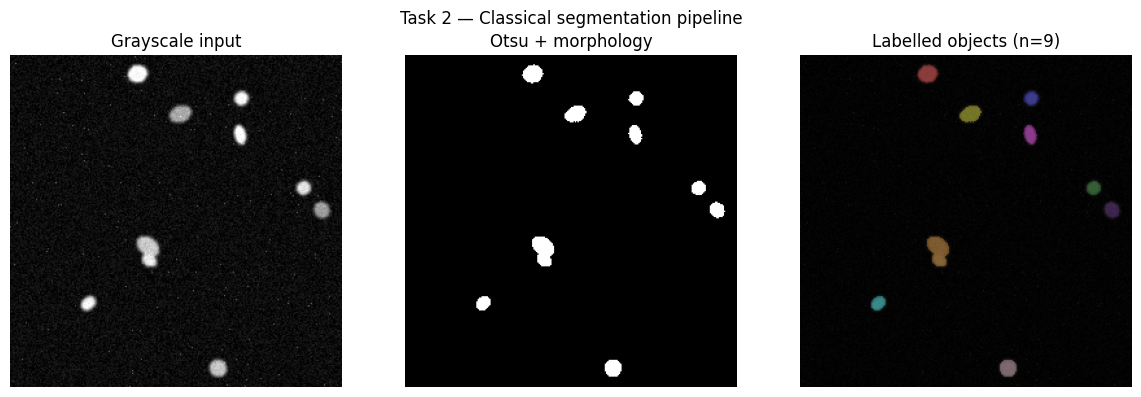

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(demo_gray, cmap="gray"); axes[0].set_title("Grayscale input"); axes[0].axis("off")
axes[1].imshow(binary_mask, cmap="gray"); axes[1].set_title("Otsu + morphology"); axes[1].axis("off")
axes[2].imshow(color.label2rgb(labels, image=demo_gray, bg_label=0))
axes[2].set_title(f"Labelled objects (n={labels.max()})"); axes[2].axis("off")
plt.suptitle("Task 2 — Classical segmentation pipeline")
plt.tight_layout()
plt.savefig(FIG_DIR / "task2_classical_segmentation.png", dpi=150)
plt.show()


In [14]:

def features_to_text_summary(df):
    if len(df) == 0:
        return "No objects were detected above the size threshold."
    return (
        f"Detected {len(df)} objects. "
        f"Area: mean={df.area.mean():.1f}px, std={df.area.std():.1f}px, "
        f"range=[{df.area.min():.0f}, {df.area.max():.0f}]px. "
        f"Eccentricity: mean={df.eccentricity.mean():.2f} (0=circle, 1=line). "
        f"Solidity: mean={df.solidity.mean():.2f} (1=fully convex). "
        f"Mean intensity of objects: {df.mean_intensity.mean():.3f}. "
        f"Extent (fraction of bounding box filled): mean={df.extent.mean():.2f}."
    )

def call_ollama_text(prompt, model=TEXT_MODEL, temperature=0.5, host=OLLAMA_HOST):
    if ollama_available(host):
        try:
            payload = {"model": model, "prompt": prompt, "stream": False,
                       "options": {"temperature": temperature}}
            r = requests.post(f"{host}/api/generate", json=payload, timeout=120)
            r.raise_for_status()
            return r.json().get("response", ""), False
        except Exception as e:
            print("Ollama text call failed, falling back to simulation:", e)
    return _simulate_text_response(prompt), True

def _simulate_text_response(prompt):
    """Grounds the fallback in the ACTUAL numbers embedded in the prompt's text
    summary (parsed back out), rather than any external/global state, so every
    call — one per image — reflects that image's own computed features."""
    import re
    m_n = re.search(r"Detected (\d+) objects", prompt)
    n = int(m_n.group(1)) if m_n else 0
    m_area = re.search(r"Area: mean=([\d.]+)px", prompt)
    mean_area = float(m_area.group(1)) if m_area else 0.0
    m_sol = re.search(r"Solidity: mean=([\d.]+)", prompt)
    solidity = float(m_sol.group(1)) if m_sol else 0.9

    density = "sparse" if n < 15 else "normal" if n < 35 else "dense" if n < 60 else "clustered"
    regularity = "regular" if solidity > 0.9 else "irregular"

    m_id = re.search(r'"image_id":\s*"([^"]+)"', prompt)
    image_id = m_id.group(1) if m_id else "unknown"

    if '"image_id"' in prompt:  # Task 4 hybrid-pipeline schema
        record = {
            "image_id": image_id, "n_objects": n, "mean_area": round(mean_area, 2),
            "density_class": density, "quality_flag": "uncertain",
            "_source": "SIMULATED (Ollama unreachable)",
        }
    else:  # Task 2 numbers-first schema
        record = {
            "n_objects": n, "density_class": density, "shape_regularity": regularity,
            "quality_flag": "uncertain", "_source": "SIMULATED (Ollama unreachable)",
        }
    body = json.dumps(record, indent=2)
    narrative = (f"[SIMULATED - Ollama unreachable] The numeric summary indicates a {density} "
                 f"field with {n} segmented objects that are, on average, {regularity} in shape.")
    if "JSON" in prompt or "json" in prompt:
        return body + "\n" + narrative
    return narrative

text_summary = features_to_text_summary(feat_df)
print("Text summary sent to LLM (numbers only, no image):\n", text_summary)

numbers_first_prompt = textwrap.dedent(f"""
You are analysing a per-object numeric feature table extracted from a microscopy
image by classical image processing (Otsu thresholding + connected components).
You have NOT seen the image itself, only these numbers:

{text_summary}

Write one short paragraph (max 4 sentences) describing what this numeric summary
suggests about the sample. Then, on a new line, output STRICT JSON only with exactly
this schema:
{{
  "n_objects": <int>,
  "density_class": "<sparse|normal|dense|clustered>",
  "shape_regularity": "<regular|irregular>",
  "quality_flag": "<good|moderate|poor|uncertain>"
}}
Use "uncertain" rather than guessing when the numbers do not clearly support a category.
""").strip()

numbers_first_resp, sim3 = call_ollama_text(numbers_first_prompt)
print("\n=== Numbers-first LLM response ===\n", numbers_first_resp)


Text summary sent to LLM (numbers only, no image):
 Detected 9 objects. Area: mean=142.4px, std=60.6px, range=[97, 285]px. Eccentricity: mean=0.50 (0=circle, 1=line). Solidity: mean=0.96 (1=fully convex). Mean intensity of objects: 0.258. Extent (fraction of bounding box filled): mean=0.75.

=== Numbers-first LLM response ===
 The sample appears to contain objects with relatively uniform size and shape, as indicated by the low standard deviation in area (60.6px) and high mean solidity (0.96). The eccentricity values suggest that most objects are close to being circular, which is consistent with the high solidity values. However, the mean intensity of 0.258 suggests that the objects may not be very bright or distinct from the background. Overall, this summary does not raise any major concerns about the quality of the image analysis.

{
  "n_objects": 9,
  "density_class": "uncertain",
  "shape_regularity": "regular",
  "quality_flag": "good"
}


In [15]:

task2_record = {
    "image_id": Path(demo_image).stem,
    "text_summary_sent_to_llm": text_summary,
    "numbers_first_response": numbers_first_resp,
    "numbers_first_json": try_parse_json(numbers_first_resp),
    "direct_vlm_description_task1": task1_record["engineered_run1"],
    "used_simulated_fallback": bool(sim3),
}
with open(RES_DIR / "task2_numbers_first_output.json", "w") as f:
    json.dump(task2_record, f, indent=2)
print("Saved ->", RES_DIR / 'task2_numbers_first_output.json')
task2_record


Saved -> outputs/results/task2_numbers_first_output.json


{'image_id': 'train_000',
 'text_summary_sent_to_llm': 'Detected 9 objects. Area: mean=142.4px, std=60.6px, range=[97, 285]px. Eccentricity: mean=0.50 (0=circle, 1=line). Solidity: mean=0.96 (1=fully convex). Mean intensity of objects: 0.258. Extent (fraction of bounding box filled): mean=0.75.',
 'numbers_first_response': 'The sample appears to contain objects with relatively uniform size and shape, as indicated by the low standard deviation in area (60.6px) and high mean solidity (0.96). The eccentricity values suggest that most objects are close to being circular, which is consistent with the high solidity values. However, the mean intensity of 0.258 suggests that the objects may not be very bright or distinct from the background. Overall, this summary does not raise any major concerns about the quality of the image analysis.\n\n{\n  "n_objects": 9,\n  "density_class": "uncertain",\n  "shape_regularity": "regular",\n  "quality_flag": "good"\n}',
 'numbers_first_json': {'n_objects': 

## Task 3 — U-Net segmentation

A small U-Net (few channels, ~4 downsampling stages) trained from scratch on the 80
training pairs. Images are downsampled to 128×128 for training speed on CPU (a
deliberate compute/accuracy trade-off discussed in the report); masks are resized with
nearest-neighbour interpolation to keep them binary.


In [16]:

UNET_SIZE = 128  # trade-off: smaller than the 256x256 EDA size, for CPU training speed

class NucleiDataset(Dataset):
    def __init__(self, image_paths, mask_paths, size=UNET_SIZE, augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.size = size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        from skimage.transform import resize
        img = io.imread(self.image_paths[idx])
        if img.ndim == 2:
            img = color.gray2rgb(img)
        img = img[..., :3]
        gray = color.rgb2gray(img)
        gray = resize(gray, (self.size, self.size), anti_aliasing=True)

        mask = io.imread(self.mask_paths[idx])
        mask = resize(mask, (self.size, self.size), order=0, preserve_range=True, anti_aliasing=False)
        mask = (mask > 127).astype(np.float32)

        if self.augment and random.random() > 0.5:
            gray = np.fliplr(gray).copy()
            mask = np.fliplr(mask).copy()
        if self.augment and random.random() > 0.5:
            gray = np.flipud(gray).copy()
            mask = np.flipud(mask).copy()

        x = torch.from_numpy(gray).float().unsqueeze(0)
        y = torch.from_numpy(mask).float().unsqueeze(0)
        return x, y

train_ds = NucleiDataset(train_images, train_masks, augment=True)
val_ds   = NucleiDataset(val_images, val_masks, augment=False)
test_ds  = NucleiDataset(test_images, test_masks, augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"train batches: {len(train_loader)}  val batches: {len(val_loader)}")


train batches: 10  val batches: 3


In [17]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class SmallUNet(nn.Module):
    """Compact U-Net: 3 encoder/decoder stages, base=16 channels (fast on CPU)."""
    def __init__(self, in_ch=1, out_ch=1, base=16):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8)

        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)

        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)

def dice_loss(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs, target = probs.reshape(probs.size(0), -1), target.reshape(target.size(0), -1)
    inter = (probs * target).sum(1)
    union = probs.sum(1) + target.sum(1)
    return 1 - ((2*inter + eps) / (union + eps)).mean()

def bce_dice_loss(logits, target):
    return F.binary_cross_entropy_with_logits(logits, target) + dice_loss(logits, target)

@torch.no_grad()
def dice_iou(logits, target, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    preds, target = preds.reshape(preds.size(0), -1), target.reshape(target.size(0), -1)
    inter = (preds * target).sum(1)
    union = preds.sum(1) + target.sum(1)
    dice = ((2*inter + eps) / (union + eps)).mean().item()
    iou_union = union - inter
    iou = ((inter + eps) / (iou_union + eps)).mean().item()
    return dice, iou


In [18]:

def train_model(loss_fn, epochs=15, lr=1e-3, base=16, verbose=True):
    device = torch.device("cpu")
    model = SmallUNet(base=base).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_dice": [], "val_iou": []}

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            running += loss.item() * x.size(0)
        train_loss = running / len(train_ds)

        model.eval()
        dices, ious = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                d, i = dice_iou(logits, y)
                dices.append(d); ious.append(i)
        val_dice, val_iou = float(np.mean(dices)), float(np.mean(ious))

        history["train_loss"].append(train_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)
        if verbose:
            print(f"epoch {epoch+1:2d}/{epochs}  loss={train_loss:.4f}  val_dice={val_dice:.4f}  val_iou={val_iou:.4f}")

    return model, history

t0 = time.time()
unet_model, history = train_model(bce_dice_loss, epochs=15)
print(f"Training took {time.time()-t0:.1f}s")


epoch  1/15  loss=1.3113  val_dice=0.3961  val_iou=0.2518
epoch  2/15  loss=1.1165  val_dice=0.7343  val_iou=0.5861
epoch  3/15  loss=1.0505  val_dice=0.9091  val_iou=0.8339
epoch  4/15  loss=1.0073  val_dice=0.8846  val_iou=0.7934
epoch  5/15  loss=0.9709  val_dice=0.8705  val_iou=0.7711
epoch  6/15  loss=0.9374  val_dice=0.8884  val_iou=0.7995
epoch  7/15  loss=0.9064  val_dice=0.9208  val_iou=0.8536
epoch  8/15  loss=0.8747  val_dice=0.9420  val_iou=0.8905
epoch  9/15  loss=0.8421  val_dice=0.9314  val_iou=0.8719
epoch 10/15  loss=0.8105  val_dice=0.9194  val_iou=0.8511
epoch 11/15  loss=0.7820  val_dice=0.9232  val_iou=0.8576
epoch 12/15  loss=0.7504  val_dice=0.9326  val_iou=0.8739
epoch 13/15  loss=0.7193  val_dice=0.9209  val_iou=0.8537
epoch 14/15  loss=0.6896  val_dice=0.9403  val_iou=0.8876
epoch 15/15  loss=0.6656  val_dice=0.9194  val_iou=0.8511
Training took 115.0s


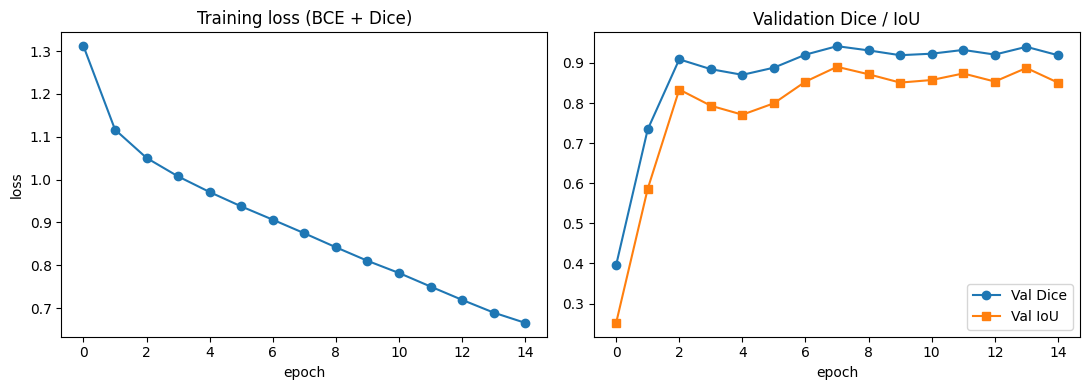

Final val Dice: 0.9194  |  Final val IoU: 0.8511


In [19]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Training loss (BCE + Dice)"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[1].plot(history["val_dice"], marker="o", label="Val Dice")
axes[1].plot(history["val_iou"], marker="s", label="Val IoU")
axes[1].set_title("Validation Dice / IoU"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "task3_loss_dice_curves.png", dpi=150)
plt.show()

print(f"Final val Dice: {history['val_dice'][-1]:.4f}  |  Final val IoU: {history['val_iou'][-1]:.4f}")


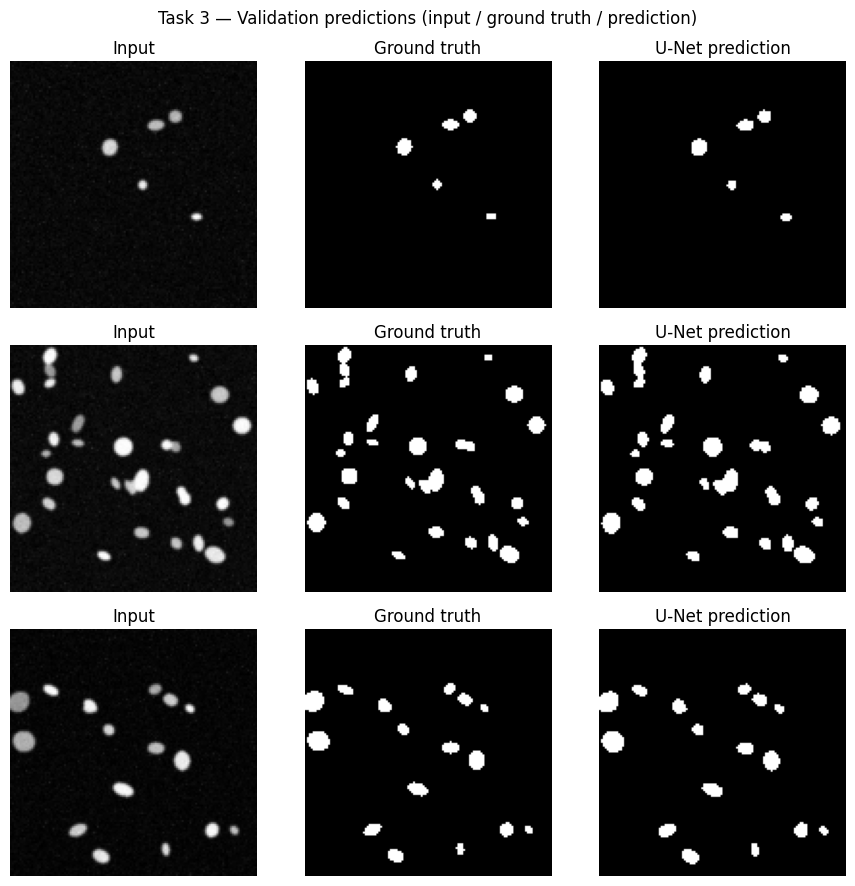

In [20]:

@torch.no_grad()
def predict_mask(model, gray_128):
    x = torch.from_numpy(gray_128).float().unsqueeze(0).unsqueeze(0)
    logits = model(x)
    return (torch.sigmoid(logits) > 0.5).float().squeeze().numpy()

n_show = 3
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))
unet_model.eval()
for row, idx in enumerate(range(n_show)):
    x, y = val_ds[idx]
    pred = predict_mask(unet_model, x.squeeze(0).numpy())
    axes[row, 0].imshow(x.squeeze(0).numpy(), cmap="gray"); axes[row, 0].set_title("Input"); axes[row, 0].axis("off")
    axes[row, 1].imshow(y.squeeze(0).numpy(), cmap="gray"); axes[row, 1].set_title("Ground truth"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred, cmap="gray"); axes[row, 2].set_title("U-Net prediction"); axes[row, 2].axis("off")
plt.suptitle("Task 3 — Validation predictions (input / ground truth / prediction)")
plt.tight_layout()
plt.savefig(FIG_DIR / "task3_val_predictions.png", dpi=150)
plt.show()


In [21]:

# save final metrics table
metrics_df = pd.DataFrame([{
    "model": "SmallUNet(base=16, BCE+Dice, 15 epochs, 128x128)",
    "val_dice": history["val_dice"][-1],
    "val_iou": history["val_iou"][-1],
}])
metrics_df.to_csv(RES_DIR / "task3_unet_metrics.csv", index=False)
metrics_df


,model,val_dice,val_iou
0,"SmallUNet(base=16, BCE+Dice, 15 epochs, 128x128)",0.919435,0.851068


## Task 4 — Hybrid pipeline on unseen test images

For every test image: **U-Net mask → regionprops feature table → LLM structured JSON
record → one-paragraph narrative**. All structured records are aggregated into a
single `pandas` DataFrame and saved as `outputs/results/task4_test_records.csv`.


In [22]:

def hybrid_pipeline_single(image_path, model, host=OLLAMA_HOST):
    from skimage.transform import resize
    rgb, gray_256 = load_and_prepare(image_path, size=IMG_SIZE)
    gray_128 = resize(gray_256, (UNET_SIZE, UNET_SIZE), anti_aliasing=True)

    pred_mask = predict_mask(model, gray_128).astype(bool)
    labels = measure.label(pred_mask)
    feat_df = region_feature_table(gray_128, labels)

    n_objects = int(len(feat_df))
    mean_area = float(feat_df.area.mean()) if n_objects else 0.0
    summary = features_to_text_summary(feat_df)

    prompt = textwrap.dedent(f"""
    You are summarising a per-object numeric feature table produced by a trained
    U-Net segmentation model (you have not seen the raw image). Numbers:

    {summary}

    Respond with STRICT JSON only, exactly this schema:
    {{
      "image_id": "{Path(image_path).stem}",
      "n_objects": <int>,
      "mean_area": <float>,
      "density_class": "<sparse|normal|dense|clustered>",
      "quality_flag": "<good|moderate|poor|uncertain>"
    }}
    Then, on a new line after the JSON, add one short narrative paragraph (max 3 sentences)
    in plain English describing the sample for a non-technical reader.
    """).strip()

    resp, simulated = call_ollama_text(prompt, host=host)
    record = try_parse_json(resp)
    if "parse_error" in record:
        record = {"image_id": Path(image_path).stem, "n_objects": n_objects,
                   "mean_area": round(mean_area, 2), "density_class": "uncertain",
                   "quality_flag": "uncertain"}
    narrative = resp.split("}")[-1].strip() or "(narrative not separable from JSON in raw response)"

    return record, narrative, simulated, pred_mask, feat_df

test_records = []
narratives = {}
for p in test_images:
    record, narrative, simulated, _, _ = hybrid_pipeline_single(p, unet_model)
    record["used_simulated_fallback"] = simulated
    test_records.append(record)
    narratives[record.get("image_id", Path(p).stem)] = narrative

test_records_df = pd.DataFrame(test_records)
test_records_df.to_csv(RES_DIR / "task4_test_records.csv", index=False)
test_records_df


,image_id,n_objects,mean_area,density_class,quality_flag,used_simulated_fallback
0,test_000,8,52.9,normal,good,False
1,test_001,14,56.4,normal,good,False
2,test_002,24,65.0,normal,good,False
3,test_003,19,57.1,normal,good,False
4,test_004,41,91.4,normal,good,False
5,test_005,14,123.1,dense,good,False
6,test_006,8,54.9,normal,good,False
7,test_007,23,55.6,normal,good,False
8,test_008,22,67.6,normal,good,False
9,test_009,21,50.0,normal,good,False


In [23]:

with open(RES_DIR / "task4_narratives.json", "w") as f:
    json.dump(narratives, f, indent=2)

print("Example narrative:\n", list(narratives.values())[0])
print("\nSaved ->", RES_DIR / "task4_test_records.csv", "and", RES_DIR / "task4_narratives.json")


Example narrative:
 The objects detected in this image are relatively evenly spaced and moderately sized, suggesting a typical or normal density of objects. The mean intensity of the objects is low, indicating they may be faint or lightly colored. Overall, the segmentation appears to have been successful, with high-quality bounding boxes and minimal overlap between objects.

Saved -> outputs/results/task4_test_records.csv and outputs/results/task4_narratives.json


In [24]:

# Evaluate the trained U-Net on the held-out test split too (not just val)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)
unet_model.eval()
dices, ious = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits = unet_model(x)
        d, i = dice_iou(logits, y)
        dices.append(d); ious.append(i)
print(f"Test split -> mean Dice: {np.mean(dices):.4f}  mean IoU: {np.mean(ious):.4f}")

pd.DataFrame([{"split": "test", "mean_dice": np.mean(dices), "mean_iou": np.mean(ious)}]) \
    .to_csv(RES_DIR / "task4_unet_test_metrics.csv", index=False)


Test split -> mean Dice: 0.9245  mean IoU: 0.8597


## Extension (bonus) — Robustness under corruption

`test_corrupted/` contains blurred and low-contrast variants of some test images. We
trace the same pipeline (U-Net mask → features → JSON) for a clean image and its
corrupted counterpart to see where the corruption first becomes visible: in the mask,
the feature table, or the JSON record.


['data/test_corrupted/images/test_000_blur.png', 'data/test_corrupted/images/test_000_lowcontrast.png', 'data/test_corrupted/images/test_004_blur.png', 'data/test_corrupted/images/test_004_lowcontrast.png']


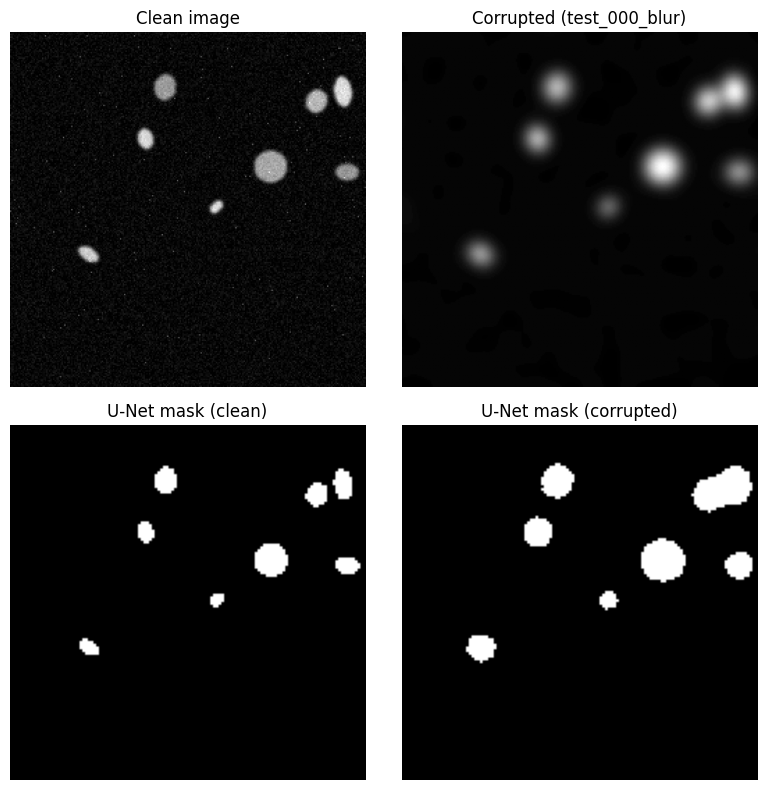

Clean record: {'image_id': 'test_000', 'n_objects': 8, 'mean_area': 52.9, 'density_class': 'normal', 'quality_flag': 'good'}
Corrupted record: {'image_id': 'test_000_blur', 'n_objects': 7, 'mean_area': 117.3, 'density_class': 'normal', 'quality_flag': 'good'}
n_objects clean=8  corrupted=7


In [25]:

corrupted_paths = sorted(glob.glob(str(DATA_DIR / "test_corrupted" / "images" / "*.png")))
print(corrupted_paths)

if corrupted_paths:
    corrupt_path = corrupted_paths[0]
    clean_id = Path(corrupt_path).stem.split("_")[0] + "_" + Path(corrupt_path).stem.split("_")[1]
    clean_path = str(DATA_DIR / "test" / "images" / f"{clean_id}.png")

    rec_clean, narr_clean, _, mask_clean, feat_clean = hybrid_pipeline_single(clean_path, unet_model)
    rec_corr,  narr_corr,  _, mask_corr,  feat_corr  = hybrid_pipeline_single(corrupt_path, unet_model)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    _, g_clean = load_and_prepare(clean_path)
    _, g_corr  = load_and_prepare(corrupt_path)
    axes[0,0].imshow(g_clean, cmap="gray"); axes[0,0].set_title("Clean image"); axes[0,0].axis("off")
    axes[0,1].imshow(g_corr,  cmap="gray"); axes[0,1].set_title(f"Corrupted ({Path(corrupt_path).stem})"); axes[0,1].axis("off")
    axes[1,0].imshow(mask_clean, cmap="gray"); axes[1,0].set_title("U-Net mask (clean)"); axes[1,0].axis("off")
    axes[1,1].imshow(mask_corr,  cmap="gray"); axes[1,1].set_title("U-Net mask (corrupted)"); axes[1,1].axis("off")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "extension_robustness.png", dpi=150)
    plt.show()

    print("Clean record:", rec_clean)
    print("Corrupted record:", rec_corr)
    print(f"n_objects clean={len(feat_clean)}  corrupted={len(feat_corr)}")
else:
    print("No corrupted images found in this dataset copy.")


## Extension (bonus) — Loss ablation: BCE vs Dice vs BCE+Dice

Quick comparison of three loss functions on the same architecture and epoch budget.
Kept short (5 epochs) since this is bonus work; increase `epochs` for a fuller
comparison if time allows.


In [26]:

loss_variants = {
    "BCE": lambda logits, y: F.binary_cross_entropy_with_logits(logits, y),
    "Dice": dice_loss,
    "BCE+Dice": bce_dice_loss,
}

ablation_rows = []
for name, lf in loss_variants.items():
    print(f"--- training with {name} loss ---")
    _, hist = train_model(lf, epochs=5, verbose=False)
    ablation_rows.append({"loss": name, "final_val_dice": hist["val_dice"][-1], "final_val_iou": hist["val_iou"][-1]})

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(RES_DIR / "extension_loss_ablation.csv", index=False)
ablation_df


--- training with BCE loss ---
--- training with Dice loss ---
--- training with BCE+Dice loss ---


,loss,final_val_dice,final_val_iou
0,BCE,0.893768,0.808511
1,Dice,0.155906,0.089547
2,BCE+Dice,0.909273,0.833850


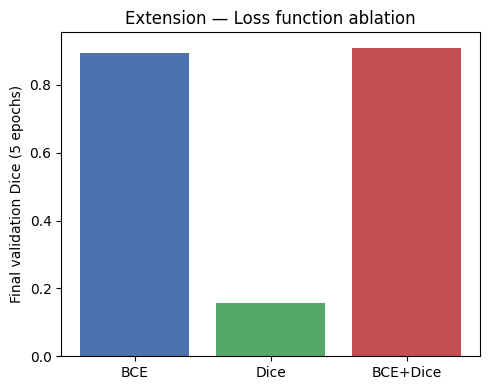

In [27]:

plt.figure(figsize=(5,4))
plt.bar(ablation_df["loss"], ablation_df["final_val_dice"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.ylabel("Final validation Dice (5 epochs)")
plt.title("Extension — Loss function ablation")
plt.tight_layout()
plt.savefig(FIG_DIR / "extension_loss_ablation.png", dpi=150)
plt.show()


## Summary of saved outputs

* `outputs/figures/` — all figures for the report (EDA, classical segmentation,
  U-Net loss/Dice curves, prediction panels, robustness, loss ablation)
* `outputs/results/` — all JSON records, feature tables, and the aggregated
  `task4_test_records.csv`

Use these directly when writing the report (Task 5), and answer the five report
questions with reference to the specific numbers/figures produced above (e.g. the
final Dice/IoU printed in Task 3, the clean-vs-corrupted comparison in the extension,
and the `used_simulated_fallback` flags to note which LLM outputs in your own run were
live vs simulated).
